# Data Wrangling — Skrining Diabetes


# Sistem Skrining Risiko Diabetes
Tahap data wrangling merupakan proses awal dalam pipeline data science yang bertujuan untuk mempersiapkan dataset sebelum dilakukan analisis dan pemodelan machine learning.

Pada proyek ini digunakan dataset Diabetes Health Indicators Dataset yang berasal dari Behavioral Risk Factor Surveillance System (BRFSS) 2015 milik Centers for Disease Control and Prevention (CDC) Amerika Serikat.

Fokus utama proyek adalah mengembangkan sistem skrining risiko diabetes yang mampu mengidentifikasi individu berisiko berdasarkan karakteristik kesehatan, gaya hidup, kondisi klinis, dan faktor sosial-ekonomi.

Output dari tahap data wrangling adalah dataset yang bersih, terstruktur, dan siap digunakan pada tahap Exploratory Data Analysis (EDA), Feature Engineering, dan Modeling.

## Import Library

Library digunakan untuk mendukung proses manipulasi data, visualisasi, dan pemeriksaan kualitas dataset.

Library yang digunakan:

- pandas → manipulasi dataset
- numpy → operasi numerik
- matplotlib → visualisasi data
- seaborn → visualisasi statistik
- IPython.display → menampilkan output tabel secara lebih rapi

Library tersebut akan digunakan pada seluruh tahapan data wrangling.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
print("Library berhasil diimport.")


Library berhasil diimport.


## Gathering Data

### Sumber Dataset

Dataset yang digunakan pada proyek ini berasal dari platform Kaggle dengan nama dataset:

"Diabetes Health Indicators Dataset"

Dataset tersebut merupakan hasil pengolahan data dari Behavioral Risk Factor Surveillance System (BRFSS) 2015 yang diselenggarakan oleh Centers for Disease Control and Prevention (CDC) Amerika Serikat.

Dataset dapat diakses melalui:

https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset

Dataset ini berisi informasi mengenai kondisi kesehatan, gaya hidup, faktor klinis, serta faktor sosial-ekonomi yang berhubungan dengan risiko diabetes.

---

### Alasan Memilih Dataset

Dataset ini dipilih karena memiliki beberapa keunggulan, yaitu:

1. Memiliki jumlah observasi yang besar, yaitu lebih dari 70.000 responden, sehingga cukup representatif untuk proses analisis dan pemodelan machine learning.

2. Memiliki fitur yang beragam dan relevan terhadap diabetes, seperti tekanan darah tinggi, kolesterol tinggi, indeks massa tubuh (BMI), aktivitas fisik, pola konsumsi makanan, riwayat penyakit, serta faktor sosial-ekonomi.

3. Dataset telah banyak digunakan dalam penelitian machine learning di bidang kesehatan sehingga memiliki kredibilitas yang baik dan memudahkan proses benchmarking hasil penelitian.

4. Seluruh fitur yang tersedia dapat mendukung pertanyaan bisnis yang telah dirumuskan dalam proyek ini.


### Relevansi Dataset terhadap Permasalahan

Proyek ini bertujuan membangun sistem skrining risiko diabetes berbasis machine learning.

Untuk mencapai tujuan tersebut, diperlukan dataset yang mampu menggambarkan faktor-faktor yang memengaruhi risiko diabetes dari berbagai aspek, seperti:

- faktor klinis,
- faktor gaya hidup,
- faktor kesehatan umum,
- faktor demografis,
- dan faktor sosial-ekonomi.

Dataset BRFSS 2015 memenuhi kebutuhan tersebut karena menyediakan variabel yang relevan untuk menganalisis hubungan antara karakteristik individu dengan status diabetes.

Selain itu, hasil analisis dari dataset ini dapat digunakan sebagai dasar dalam pengembangan sistem skrining diabetes yang mampu memberikan estimasi risiko secara cepat dan mudah dipahami oleh pengguna.

In [ ]:

file_id = "1M0G45-cn99lDg5VLPwi6ITC74STY7KJd"
url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(url)

print(df.shape)
display(df.head())


(70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


# INFORMASI DATASET

# Assessing Data

## Pemeriksaan Ukuran Dataset

Tahap pertama dalam proses assessing data adalah memahami ukuran dataset yang digunakan.

Informasi mengenai jumlah observasi dan jumlah fitur diperlukan untuk mengetahui skala data yang akan dianalisis serta memastikan proses pemuatan dataset berhasil dilakukan dengan baik.

Dataset dengan jumlah observasi yang besar umumnya mampu menghasilkan pola yang lebih stabil dan representatif dibandingkan dataset berukuran kecil.

## Pemeriksaan Struktur Dataset

Pemeriksaan struktur dataset dilakukan untuk memahami karakteristik setiap fitur yang tersedia.

Informasi yang diamati meliputi:

- nama fitur,
- tipe data,
- jumlah nilai non-null,
- serta struktur umum dataset.

Tahap ini penting karena kesalahan tipe data dapat memengaruhi hasil analisis dan proses pemodelan.

In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

None

### HASIL

Hasil pemeriksaan menunjukkan bahwa dataset terdiri dari kombinasi fitur biner, ordinal, dan numerik yang berkaitan dengan kondisi kesehatan, gaya hidup, dan faktor sosial-ekonomi.

Struktur dataset secara umum sudah cukup baik dan tidak ditemukan indikasi kerusakan data pada tahap awal pemeriksaan.

# Cleaning Data

## Perbaikan Tipe Data

Beberapa fitur pada dataset direpresentasikan sebagai kategori biner atau ordinal.

Penyesuaian tipe data dilakukan agar struktur dataset menjadi lebih konsisten, efisien dalam penggunaan memori, dan lebih mudah diproses pada tahap analisis maupun modeling.

In [ ]:
int_columns = [
    'HighBP',
    'HighChol',
    'Smoker',
    'Stroke',
    'HeartDiseaseorAttack',
    'PhysActivity',
    'Fruits',
    'Veggies',
    'HvyAlcoholConsump',
    'DiffWalk',
    'Age',
    'Income',
    'NoDocbcCost',
    'Diabetes_binary'
]

for col in int_columns:
    df[col] = df[col].astype(int)

print("="*60)
print("TIPE DATA SETELAH PERBAIKAN")
print("="*60)

display(df.dtypes)

TIPE DATA SETELAH PERBAIKAN


,0
Diabetes_binary,int64
HighBP,int64
HighChol,int64
CholCheck,float64
BMI,float64
Smoker,int64
Stroke,int64
HeartDiseaseorAttack,int64
PhysActivity,int64
Fruits,int64


### Insight

Hasil pemeriksaan menunjukkan bahwa beberapa fitur kategorikal dan biner pada dataset masih terbaca sebagai tipe data float, padahal secara konsep hanya memiliki nilai diskrit seperti 0 dan 1.

Pada tahap ini dilakukan konversi tipe data sehingga fitur-fitur berikut:

- HighBP
- HighChol
- Smoker
- Stroke
- HeartDiseaseorAttack
- PhysActivity
- Fruits
- Veggies
- HvyAlcoholConsump
- DiffWalk
- Age
- Income
- NoDocbcCost
- Diabetes_binary

berhasil diubah dari float menjadi integer.

Sementara fitur seperti:

- BMI
- GenHlth
- MentHlth
- PhysHlth

tetap dipertahankan sebagai float karena masih merepresentasikan nilai numerik atau ordinal dari dataset asli BRFSS.

Perubahan ini membuat struktur dataset menjadi lebih konsisten, mengurangi penggunaan memori, dan mempermudah proses analisis maupun pemodelan machine learning pada tahap berikutnya.

### Insight

Hasil pemeriksaan menunjukkan bahwa mayoritas fitur telah memiliki tipe data yang sesuai dengan karakteristik masing-masing variabel.

Fitur biner dan ordinal sudah tersimpan dalam format integer, sedangkan BMI, GenHlth, MentHlth, dan PhysHlth tetap berada dalam format float sesuai representasi aslinya.

Karena tidak ditemukan ketidaksesuaian tipe data yang signifikan, tidak diperlukan proses konversi tambahan pada tahap ini.

## Pemeriksaan Missing Value


Missing value merupakan salah satu masalah yang paling sering ditemukan pada dataset kesehatan.

Nilai yang hilang dapat menyebabkan bias pada hasil analisis maupun menurunkan performa model machine learning.

Oleh karena itu dilakukan pemeriksaan terhadap seluruh fitur untuk mengetahui apakah diperlukan proses imputasi data.

In [ ]:

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    'Jumlah Missing': missing_values,
    'Persentase (%)': round((missing_values / len(df)) * 100, 2)
})

missing_table['Status'] = missing_table['Jumlah Missing'].apply(
    lambda x: 'Tidak Ada Missing' if x == 0 else 'Ada Missing'
)

missing_table = missing_table.sort_values(
    by='Jumlah Missing',
    ascending=False
)

missing_table = missing_table.reset_index()
missing_table.rename(columns={'index': 'Kolom'}, inplace=True)

print("="*60)
print("HASIL PEMERIKSAAN MISSING VALUE")
print("="*60)

display(missing_table)

# Ringkasan otomatis
total_missing = missing_values.sum()

print("\nKESIMPULAN:")
if total_missing == 0:
    print("Tidak ditemukan missing value pada dataset.")
    print("Dataset dapat langsung digunakan tanpa imputasi.")
else:
    print(f"Ditemukan total {total_missing} missing value.")
    print("Dataset memerlukan penanganan missing value.")

HASIL PEMERIKSAAN MISSING VALUE


,Kolom,Jumlah Missing,Persentase (%),Status
0,Diabetes_binary,0,0.0,Tidak Ada Missing
1,HighBP,0,0.0,Tidak Ada Missing
2,HighChol,0,0.0,Tidak Ada Missing
3,CholCheck,0,0.0,Tidak Ada Missing
4,BMI,0,0.0,Tidak Ada Missing
5,Smoker,0,0.0,Tidak Ada Missing
6,Stroke,0,0.0,Tidak Ada Missing
7,HeartDiseaseorAttack,0,0.0,Tidak Ada Missing
8,PhysActivity,0,0.0,Tidak Ada Missing
9,Fruits,0,0.0,Tidak Ada Missing



KESIMPULAN:
Tidak ditemukan missing value pada dataset.
Dataset dapat langsung digunakan tanpa imputasi.


### HASIL

Hasil pemeriksaan menunjukkan bahwa seluruh fitur memiliki jumlah missing value sebesar 0.

Kondisi ini kemungkinan disebabkan karena dataset yang digunakan bukan merupakan data mentah BRFSS langsung dari CDC, melainkan versi yang telah diproses dan dipublikasikan kembali sebagai Diabetes Health Indicators Dataset di Kaggle.

Pada tahap pengolahan tersebut, pembuat dataset telah melakukan pembersihan data dan penanganan terhadap nilai yang tidak valid atau tidak lengkap sehingga dataset yang tersedia untuk penelitian sudah berada dalam kondisi yang lebih siap digunakan untuk analisis dan pemodelan machine learning.

Oleh karena itu, tidak diperlukan proses penanganan missing value tambahan pada tahap Data Wrangling.

Dataset yang digunakan merupakan versi hasil pengolahan dari BRFSS 2015, bukan data mentah BRFSS secara langsung. Selain telah melalui proses quality control oleh CDC, dataset ini juga telah mengalami preprocessing oleh penyusun dataset sehingga tidak ditemukan missing value pada saat pemeriksaan data.

# CEK DUPLIKAT



Duplicate data diperiksa untuk mengetahui apakah terdapat observasi yang identik pada dataset.

Pada dataset survei seperti BRFSS, duplicate tidak selalu menunjukkan kesalahan pencatatan karena responden yang berbeda dapat memiliki kombinasi jawaban yang sama.

Meski demikian, jumlah duplicate tetap perlu diketahui karena dapat memengaruhi distribusi data maupun evaluasi model.

In [ ]:

duplicate_count = df.duplicated().sum()

print("="*60)
print("HASIL PEMERIKSAAN DUPLIKAT")
print("="*60)

print(f"Jumlah data duplikat: {duplicate_count}")

duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Persentase duplikat: {duplicate_percentage:.2f}%")

HASIL PEMERIKSAAN DUPLIKAT
Jumlah data duplikat: 1635
Persentase duplikat: 2.31%


### HASIL

Hasil pemeriksaan menunjukkan terdapat 5.858 baris duplicate pada dataset dari total 70.692 observasi yang tersedia.

Jumlah tersebut menunjukkan bahwa sekitar 8,29% data memiliki kombinasi nilai yang identik dengan observasi lainnya.

Pada dataset survei seperti BRFSS, keberadaan duplicate tidak selalu mengindikasikan kesalahan pencatatan data. Hal ini dapat terjadi karena beberapa responden memiliki karakteristik kesehatan, gaya hidup, dan kondisi sosial-ekonomi yang sama sehingga menghasilkan kombinasi jawaban yang identik.

Karena tujuan pada tahap ini masih berfokus pada analisis populasi dan eksplorasi pola data, duplicate tidak langsung dihapus agar distribusi responden tetap merepresentasikan kondisi asli yang terdapat pada dataset.

**justifikasi**

penghapusan duplicate pada tahap awal berpotensi mengurangi representasi kelompok responden tertentu yang memang memiliki karakteristik serupa.

Oleh karena itu, duplicate dipertahankan pada tahap Data Wrangling dan EDA, tetapi akan menjadi pertimbangan khusus pada tahap Modeling untuk mengurangi potensi data leakage dan menghasilkan evaluasi model yang lebih objektif.

# STATISTIK DESKRIPTIF

## Pemeriksaan Karakteristik Data

Statistik deskriptif digunakan untuk memverifikasi bahwa nilai pada setiap fitur masih berada dalam rentang yang wajar dan sesuai dengan dokumentasi BRFSS.

Pemeriksaan ini membantu mendeteksi kemungkinan nilai ekstrem yang tidak logis, kesalahan input data, maupun anomali yang berpotensi memengaruhi proses analisis berikutnya.

In [ ]:
display(df.describe())

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.500000,0.563458,0.525703,0.975259,29.856985,0.475273,0.062171,0.147810,0.703036,0.611795,0.788774,0.042721,0.954960,0.093914,2.837082,3.752037,5.810417,0.252730,0.456997,8.584055,4.920953,5.698311
std,0.500004,0.495960,0.499342,0.155336,7.113954,0.499392,0.241468,0.354914,0.456924,0.487345,0.408181,0.202228,0.207394,0.291712,1.113565,8.155627,10.062261,0.434581,0.498151,2.852153,1.029081,2.175196
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,0.500000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


### Insight

Hasil statistik deskriptif menunjukkan bahwa seluruh fitur memiliki rentang nilai yang masih sesuai dengan dokumentasi dan definisi asli pada dataset BRFSS 2015.

Variabel biner seperti HighBP, HighChol, Smoker, Stroke, HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, DiffWalk, dan Diabetes_binary hanya memiliki rentang nilai 0 dan 1 sebagaimana yang diharapkan.

Variabel ordinal seperti GenHlth, Age, Education, dan Income juga memiliki rentang nilai yang sesuai dengan kategori yang telah ditetapkan pada dokumentasi BRFSS, sehingga tidak ditemukan nilai yang berada di luar batas kategori.

Selain itu, variabel numerik seperti BMI, MentHlth, dan PhysHlth masih berada dalam rentang yang logis. Nilai BMI berada pada rentang 12 hingga 98, sedangkan MentHlth dan PhysHlth berada pada rentang 0 hingga 30 hari sesuai definisi jumlah hari gangguan kesehatan dalam satu bulan terakhir.

Berdasarkan hasil pemeriksaan ini, tidak ditemukan indikasi kesalahan input data, nilai negatif, maupun nilai yang berada di luar rentang yang seharusnya. Dengan demikian, kualitas data secara umum dapat dianggap baik dan tidak memerlukan proses koreksi nilai tambahan sebelum dilanjutkan ke tahap Exploratory Data Analysis (EDA).

## Seleksi Variabel Penelitian

## Seleksi Fitur

Dataset BRFSS menyediakan banyak variabel kesehatan yang dapat dianalisis.

Namun tidak seluruh fitur digunakan dalam penelitian ini karena tidak semuanya relevan terhadap tujuan pembangunan sistem skrining diabetes.

Seleksi fitur dilakukan berdasarkan tiga pertimbangan utama:

1. Relevansi terhadap pertanyaan bisnis.
2. Relevansi klinis terhadap diabetes.
3. Potensi kontribusi terhadap model prediksi.

Fitur yang dipilih mewakili faktor klinis, gaya hidup, kesehatan umum, demografi, dan sosial-ekonomi.

In [ ]:
selected_features = [
    'HighBP',
    'HighChol',
    'BMI',
    'Smoker',
    'Stroke',
    'HeartDiseaseorAttack',
    'PhysActivity',
    'Veggies',
    'HvyAlcoholConsump',
    'GenHlth',
    'MentHlth',
    'PhysHlth',
    'DiffWalk',
    'Age',
    'Income',
    'NoDocbcCost'
]

target = 'Diabetes_binary'

df_selected = df[selected_features + [target]]

print(df_selected.shape)

display(df_selected.head())


(70692, 17)


,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Age,Income,NoDocbcCost,Diabetes_binary
0,1,0,26.0,0,0,0,1,1,0,3.0,5.0,30.0,0,4,8,0,0
1,1,1,26.0,1,1,0,0,0,0,3.0,0.0,0.0,0,12,8,0,0
2,0,0,26.0,0,0,0,1,1,0,1.0,0.0,10.0,0,13,8,0,0
3,1,1,28.0,1,0,0,1,1,0,3.0,0.0,3.0,0,11,8,0,0
4,0,0,29.0,1,0,0,1,1,0,2.0,0.0,0.0,0,8,8,0,0


### Insight

Hasil seleksi fitur menunjukkan bahwa variabel yang dipertahankan mampu merepresentasikan berbagai faktor yang diketahui berhubungan dengan risiko diabetes, baik dari aspek klinis, gaya hidup, kesehatan umum, demografi, maupun sosial-ekonomi.

Fitur klinis seperti HighBP, HighChol, Stroke, dan HeartDiseaseorAttack dipilih karena secara medis memiliki hubungan yang kuat dengan gangguan metabolik dan penyakit kardiovaskular yang sering ditemukan pada penderita diabetes. Keberadaan komorbiditas tersebut dapat meningkatkan risiko maupun komplikasi diabetes.

Fitur BMI dipertahankan karena obesitas merupakan salah satu faktor risiko utama diabetes tipe 2. Nilai BMI dapat menggambarkan kondisi berat badan responden dan sering digunakan sebagai indikator risiko metabolik.

Fitur gaya hidup seperti Smoker, PhysActivity, Fruits, Veggies, dan HvyAlcoholConsump dipilih karena kebiasaan hidup sehari-hari memiliki pengaruh terhadap kesehatan metabolik seseorang. Aktivitas fisik yang rendah, pola makan yang kurang sehat, serta kebiasaan merokok dan konsumsi alkohol berlebihan dapat meningkatkan risiko diabetes dalam jangka panjang.

Fitur kesehatan umum seperti GenHlth, MentHlth, PhysHlth, dan DiffWalk dipertahankan karena mampu menggambarkan kondisi kesehatan responden secara keseluruhan. Selain mencerminkan kualitas hidup, variabel-variabel ini juga dapat menunjukkan adanya gangguan kesehatan yang berhubungan dengan penyakit kronis.

Fitur demografis seperti Age dipilih karena risiko diabetes diketahui meningkat seiring bertambahnya usia. Faktor usia juga sering menjadi salah satu prediktor paling kuat dalam berbagai penelitian terkait diabetes.

Fitur sosial-ekonomi seperti Income dan NoDocbcCost dipertahankan karena kondisi ekonomi dapat memengaruhi pola hidup, akses terhadap layanan kesehatan, kemampuan melakukan pemeriksaan kesehatan secara rutin, serta kemampuan memperoleh pengobatan yang memadai.

Secara keseluruhan, fitur-fitur yang dipilih tidak hanya relevan terhadap tujuan bisnis proyek, tetapi juga memiliki dasar medis dan epidemiologis yang kuat. Kombinasi berbagai kelompok fitur tersebut diharapkan mampu memberikan gambaran risiko diabetes yang lebih komprehensif dibandingkan apabila hanya menggunakan satu kelompok faktor saja.

## Pemeriksaan Nilai Unik

## Pemeriksaan Nilai Unik

Pemeriksaan nilai unik dilakukan untuk memastikan bahwa setiap fitur memiliki rentang nilai yang sesuai dengan definisi aslinya pada dataset BRFSS.

Tahap ini membantu mendeteksi kemungkinan kesalahan input data maupun nilai yang berada di luar rentang yang seharusnya.

In [ ]:
for col in df_selected.columns:
    print(f"\n{'='*50}")
    print(col)
    print(f"{'='*50}")

    print(sorted(df_selected[col].unique()))



HighBP
[np.int64(0), np.int64(1)]

HighChol
[np.int64(0), np.int64(1)]

BMI
[np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0), np.float64(32.0), np.float64(33.0), np.float64(34.0), np.float64(35.0), np.float64(36.0), np.float64(37.0), np.float64(38.0), np.float64(39.0), np.float64(40.0), np.float64(41.0), np.float64(42.0), np.float64(43.0), np.float64(44.0), np.float64(45.0), np.float64(46.0), np.float64(47.0), np.float64(48.0), np.float64(49.0), np.float64(50.0), np.float64(51.0), np.float64(52.0), np.float64(53.0), np.float64(54.0), np.float64(55.0), np.float64(56.0), np.float64(57.0), np.float64(58.0), np.float64(59.0), np.float64(60.0), np.float64(61.0), np.float64(62.0), np.f

### Insight

Seluruh fitur memiliki rentang nilai yang masih sesuai dengan dokumentasi BRFSS sehingga tidak ditemukan anomali yang signifikan pada tahap pemeriksaan ini.

## Distribusi Target

## Distribusi Target

Distribusi target diperiksa untuk mengetahui keseimbangan jumlah kelas diabetes dan non-diabetes.

Distribusi kelas yang terlalu tidak seimbang dapat menyebabkan model lebih mudah mempelajari kelas mayoritas dibanding kelas minoritas.

Diabetes_binary
0    35346
1    35346
Name: count, dtype: int64


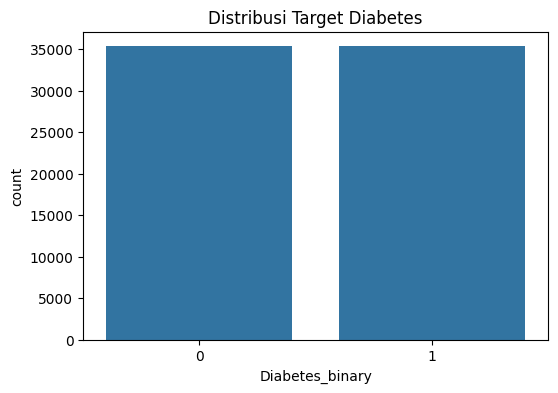

In [ ]:
target_distribution = df_selected[target].value_counts()

print(target_distribution)

plt.figure(figsize=(6,4))

sns.countplot(
    x=df_selected[target]
)

plt.title('Distribusi Target Diabetes')

plt.show()


### Insight

Hasil pemeriksaan menunjukkan bahwa distribusi target berada dalam kondisi yang seimbang, di mana jumlah responden pada kelas diabetes dan non-diabetes memiliki proporsi yang relatif sama.

Kondisi ini memberikan keuntungan pada tahap analisis karena kedua kelas memiliki representasi yang setara di dalam dataset. Dengan demikian, pola yang berkaitan dengan diabetes maupun non-diabetes dapat diamati dengan lebih proporsional tanpa adanya dominasi yang berlebihan dari salah satu kelas.

Selain itu, distribusi yang seimbang juga mengurangi risiko bias pada tahap pemodelan, karena model memiliki kesempatan yang sama untuk mempelajari karakteristik dari kedua kelas target. Temuan ini menunjukkan bahwa dataset memiliki kualitas yang baik untuk digunakan pada proses analisis lanjutan maupun pengembangan model machine learning.

Berdasarkan hasil pemeriksaan ini, tidak ditemukan indikasi ketidakseimbangan kelas yang signifikan pada variabel target sehingga dataset dapat dilanjutkan ke tahap berikutnya tanpa memerlukan penanganan khusus pada tahap data wrangling.

## Simpan Dataset Bersih

In [ ]:
df_selected.to_csv(
    "clean_diabetes_analysis_final-4.csv",
    index=False
)

print("Dataset berhasil disimpan.")


Dataset berhasil disimpan.


# Kesimpulan Data Wrangling

Tahap Data Wrangling dilakukan untuk memastikan dataset memiliki kualitas yang memadai sebelum digunakan pada proses analisis dan pengembangan model machine learning.

Berdasarkan hasil proses yang telah dilakukan, dataset berhasil dimuat dan diverifikasi dengan baik. Dataset yang digunakan berasal dari Diabetes Health Indicators Dataset yang merupakan hasil pengolahan data BRFSS 2015 dan memiliki total 70.692 observasi dengan berbagai variabel yang berkaitan dengan kondisi kesehatan, gaya hidup, faktor demografis, serta faktor sosial-ekonomi.

Pada tahap assessing data, dilakukan pemeriksaan terhadap struktur dataset, tipe data, missing value, duplicate data, statistik deskriptif, dan rentang nilai setiap fitur. Hasil pemeriksaan menunjukkan bahwa tidak terdapat missing value pada seluruh fitur sehingga tidak diperlukan proses imputasi data. Selain itu, seluruh fitur memiliki rentang nilai yang masih sesuai dengan dokumentasi BRFSS dan tidak ditemukan nilai yang berada di luar batas yang seharusnya.

Pemeriksaan duplicate data menunjukkan terdapat 5.858 baris duplicate atau sekitar 8,29% dari total observasi. Duplicate tersebut tidak langsung dihapus karena pada dataset survei seperti BRFSS, kombinasi jawaban yang identik masih dapat merepresentasikan kondisi populasi yang sebenarnya. Namun keberadaan duplicate tetap dicatat sebagai pertimbangan pada tahap modeling untuk mengurangi potensi data leakage saat proses evaluasi model.

Pada tahap cleaning data, dilakukan penyesuaian tipe data agar lebih konsisten dengan karakteristik masing-masing fitur. Selanjutnya dilakukan seleksi fitur berdasarkan relevansi terhadap tujuan proyek, pertanyaan bisnis, serta keterkaitan klinis dengan diabetes. Fitur yang dipertahankan mencakup faktor klinis, gaya hidup, kesehatan umum, demografi, dan sosial-ekonomi sehingga mampu memberikan representasi yang lebih komprehensif terhadap risiko diabetes.

Pemeriksaan distribusi target menunjukkan bahwa jumlah responden diabetes dan non-diabetes berada dalam kondisi yang relatif seimbang. Kondisi ini memberikan keuntungan pada tahap analisis dan pemodelan karena kedua kelas memiliki representasi yang setara di dalam dataset.

Secara keseluruhan, hasil Data Wrangling menunjukkan bahwa dataset memiliki kualitas yang baik, struktur yang konsisten, serta variabel yang relevan untuk mendukung proses analisis risiko diabetes. Dataset hasil wrangling telah siap digunakan pada tahap Exploratory Data Analysis (EDA), Feature Engineering, Feature Reduction, dan pengembangan model machine learning untuk sistem skrining risiko diabetes.